<a href="https://colab.research.google.com/github/AnisaML07/chronicroisk-ke/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 ChronicRisk KE — Exploratory Data Analysis
### Phase 2 of 4 | CRISP-DM: Data Understanding

This notebook explores the ChronicRisk KE dataset to uncover patterns,
distributions, and relationships between risk factors and chronic disease
outcomes across Kenya's 47 counties.

**Charts produced:**
1. Disease prevalence overview
2. Age distribution by disease status
3. BMI distribution by disease status
4. Disease prevalence by gender
5. Disease prevalence by residence (Urban vs Rural)
6. Disease prevalence by wealth level
7. Disease prevalence by education level
8. Disease prevalence by county (top 15)
9. Smoking and alcohol vs disease
10. Correlation heatmap

In [1]:
# ── Import libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Libraries ready")

✅ Libraries ready


In [2]:
# ── Load the cleaned dataset ─────────────────────────────────────────────
df = pd.read_csv('ChronicRiskKE_final.csv')

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

✅ Dataset loaded: 28,494 rows × 11 columns

Columns: ['gender', 'age', 'county', 'residence', 'education', 'wealth', 'bmi', 'smokes', 'alcohol_days', 'hypertension', 'diabetes']


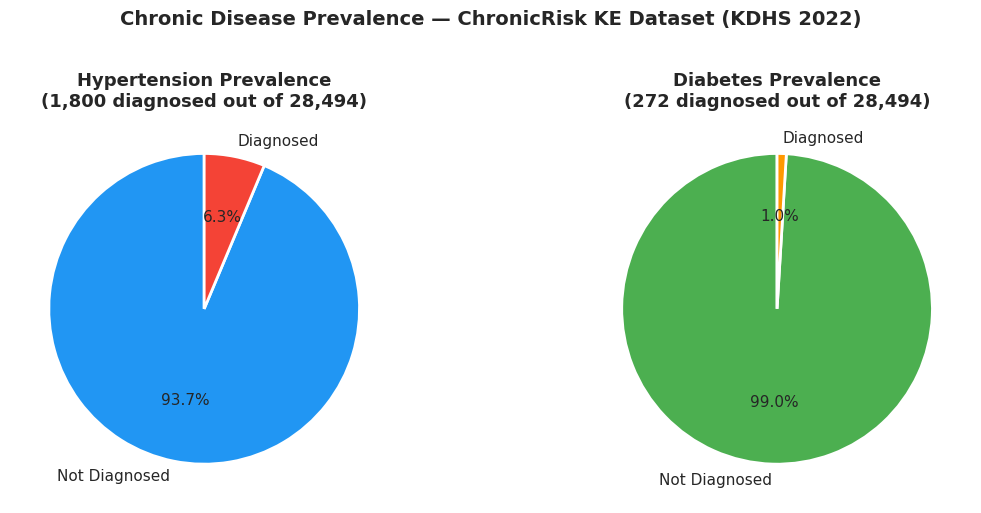

✅ Chart 1 saved


In [3]:
# ── Chart 1: Disease Prevalence Overview ─────────────────────────────────
# How many people in our dataset have hypertension vs diabetes?

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

diseases = ['hypertension', 'diabetes']
titles   = ['Hypertension', 'Diabetes']
colors   = [['#2196F3', '#F44336'], ['#4CAF50', '#FF9800']]

for i, (disease, title, color) in enumerate(zip(diseases, titles, colors)):
    counts = df[disease].value_counts()
    labels = ['Not Diagnosed', 'Diagnosed']
    axes[i].pie(
        counts,
        labels=labels,
        autopct='%1.1f%%',
        colors=color,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[i].set_title(f'{title} Prevalence\n({counts[1]:,} diagnosed out of {len(df):,})',
                      fontsize=13, fontweight='bold')

plt.suptitle('Chronic Disease Prevalence — ChronicRisk KE Dataset (KDHS 2022)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_disease_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

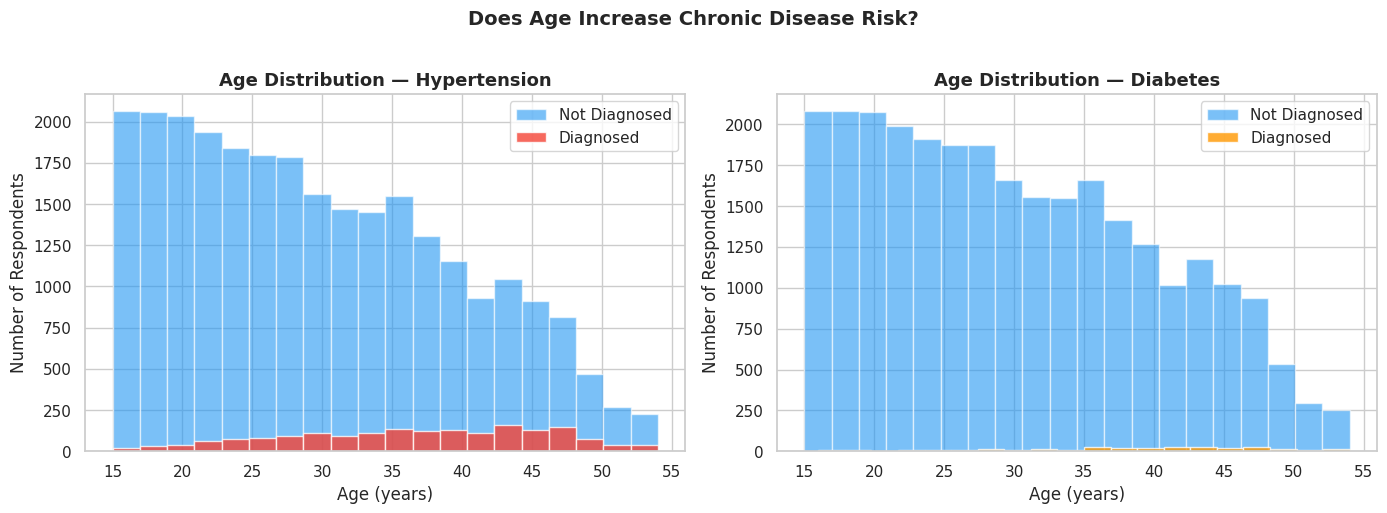

✅ Chart 2 saved


In [4]:
# ── Chart 2: Age Distribution by Disease Status ───────────────────────────
# Does age increase the risk of hypertension and diabetes?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (disease, title, color) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes'],
    ['#F44336', '#FF9800']
)):
    axes[i].hist(
        df[df[disease] == 0]['age'],
        bins=20, alpha=0.6, color='#2196F3', label='Not Diagnosed', edgecolor='white'
    )
    axes[i].hist(
        df[df[disease] == 1]['age'],
        bins=20, alpha=0.8, color=color, label='Diagnosed', edgecolor='white'
    )
    axes[i].set_title(f'Age Distribution — {title}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Age (years)')
    axes[i].set_ylabel('Number of Respondents')
    axes[i].legend()

plt.suptitle('Does Age Increase Chronic Disease Risk?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

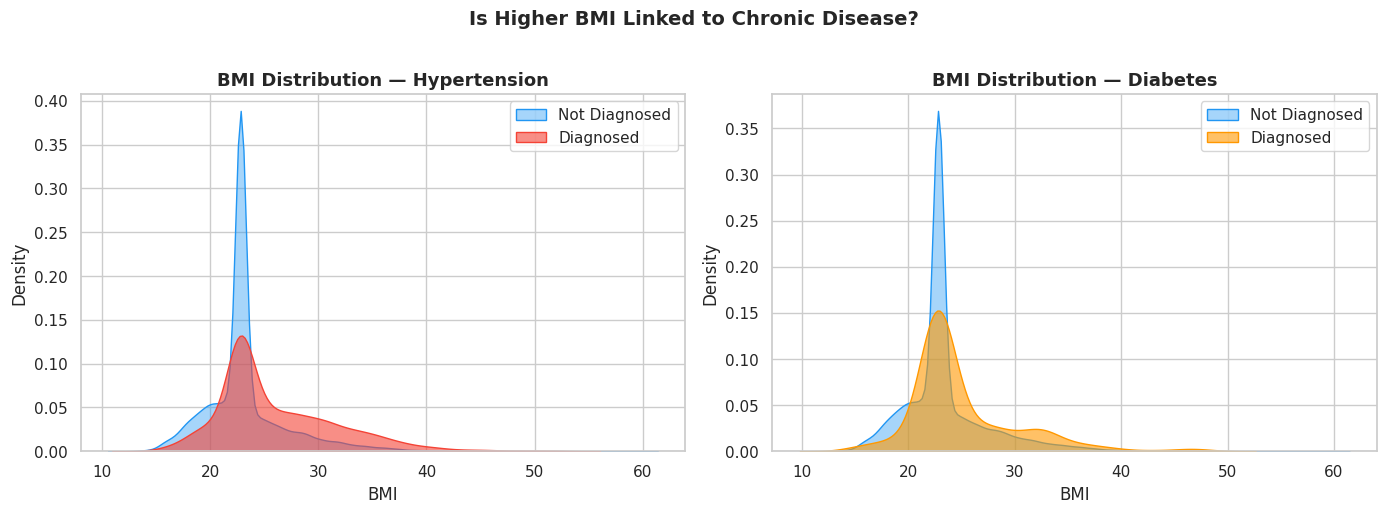

✅ Chart 3 saved


In [5]:
# ── Chart 3: BMI Distribution by Disease Status ───────────────────────────
# Is higher BMI linked to hypertension and diabetes?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (disease, title, color) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes'],
    ['#F44336', '#FF9800']
)):
    sns.kdeplot(
        df[df[disease] == 0]['bmi'],
        ax=axes[i], color='#2196F3', fill=True, alpha=0.4, label='Not Diagnosed'
    )
    sns.kdeplot(
        df[df[disease] == 1]['bmi'],
        ax=axes[i], color=color, fill=True, alpha=0.6, label='Diagnosed'
    )
    axes[i].set_title(f'BMI Distribution — {title}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('BMI')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Is Higher BMI Linked to Chronic Disease?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

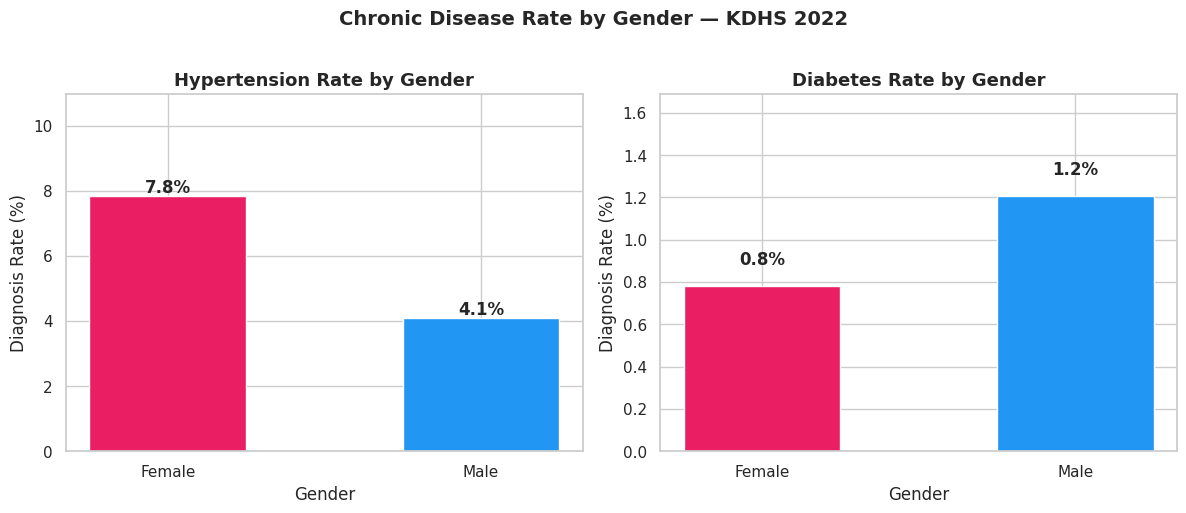

✅ Chart 4 saved


In [6]:
# ── Chart 4: Disease Prevalence by Gender ────────────────────────────────
# Are men or women more likely to be diagnosed?

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (disease, title) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes']
)):
    gender_disease = df.groupby('gender')[disease].mean() * 100

    bars = axes[i].bar(
        gender_disease.index,
        gender_disease.values,
        color=['#E91E63', '#2196F3'],
        edgecolor='white',
        width=0.5
    )
    axes[i].set_title(f'{title} Rate by Gender', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Diagnosis Rate (%)')
    axes[i].set_ylim(0, gender_disease.max() * 1.4)

    for bar, val in zip(bars, gender_disease.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=12
        )

plt.suptitle('Chronic Disease Rate by Gender — KDHS 2022',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_gender_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

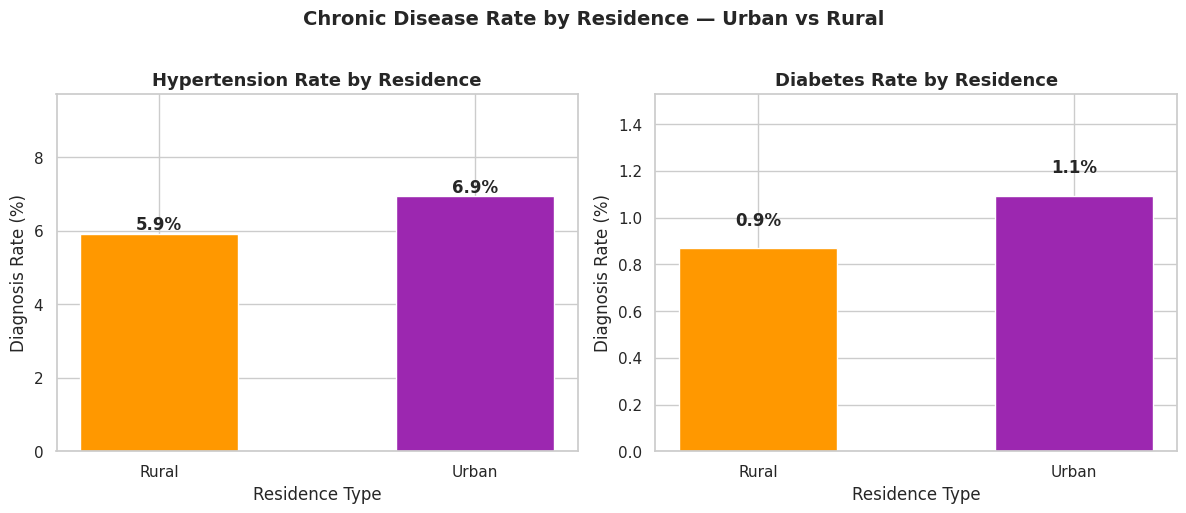

✅ Chart 5 saved


In [7]:
# ── Chart 5: Disease Prevalence by Residence ─────────────────────────────
# Are urban or rural residents more at risk?

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (disease, title) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes']
)):
    res_disease = df.groupby('residence')[disease].mean() * 100

    bars = axes[i].bar(
        res_disease.index,
        res_disease.values,
        color=['#FF9800', '#9C27B0'],
        edgecolor='white',
        width=0.5
    )
    axes[i].set_title(f'{title} Rate by Residence', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Residence Type')
    axes[i].set_ylabel('Diagnosis Rate (%)')
    axes[i].set_ylim(0, res_disease.max() * 1.4)

    for bar, val in zip(bars, res_disease.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=12
        )

plt.suptitle('Chronic Disease Rate by Residence — Urban vs Rural',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart5_residence_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

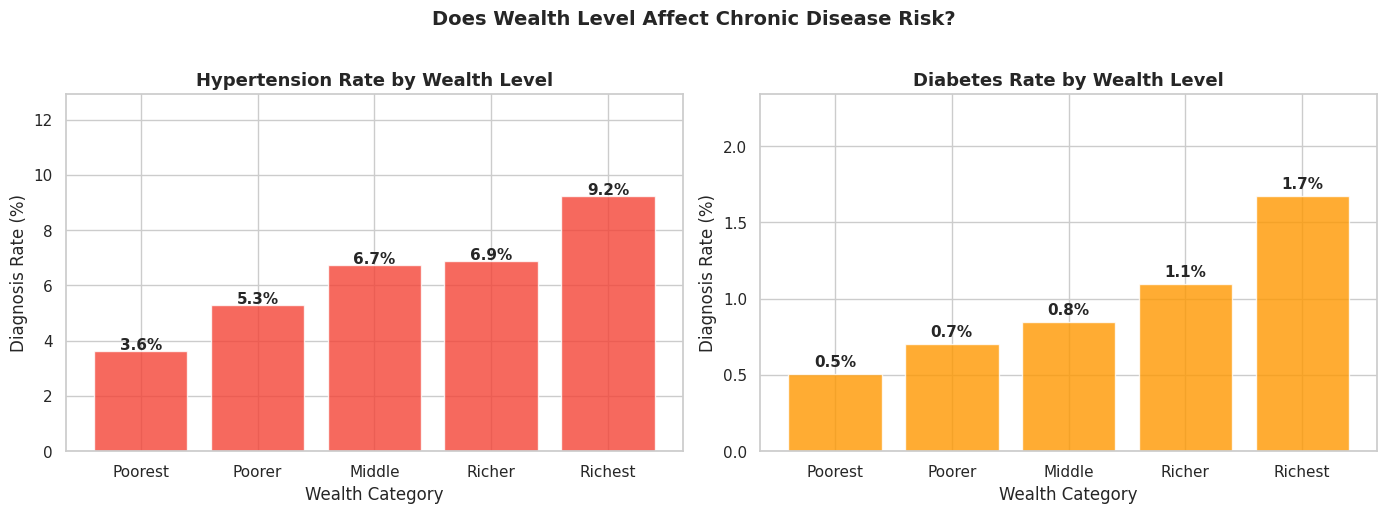

✅ Chart 6 saved


In [8]:
# ── Chart 6: Disease Prevalence by Wealth Level ───────────────────────────
# Do wealthier Kenyans have higher or lower chronic disease rates?

wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (disease, title, color) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes'],
    ['#F44336', '#FF9800']
)):
    wealth_disease = df.groupby('wealth')[disease].mean() * 100
    wealth_disease = wealth_disease.reindex(wealth_order)

    bars = axes[i].bar(
        wealth_disease.index,
        wealth_disease.values,
        color=color,
        alpha=0.8,
        edgecolor='white'
    )
    axes[i].set_title(f'{title} Rate by Wealth Level', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Wealth Category')
    axes[i].set_ylabel('Diagnosis Rate (%)')
    axes[i].set_ylim(0, wealth_disease.max() * 1.4)

    for bar, val in zip(bars, wealth_disease.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=11
        )

plt.suptitle('Does Wealth Level Affect Chronic Disease Risk?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_wealth_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

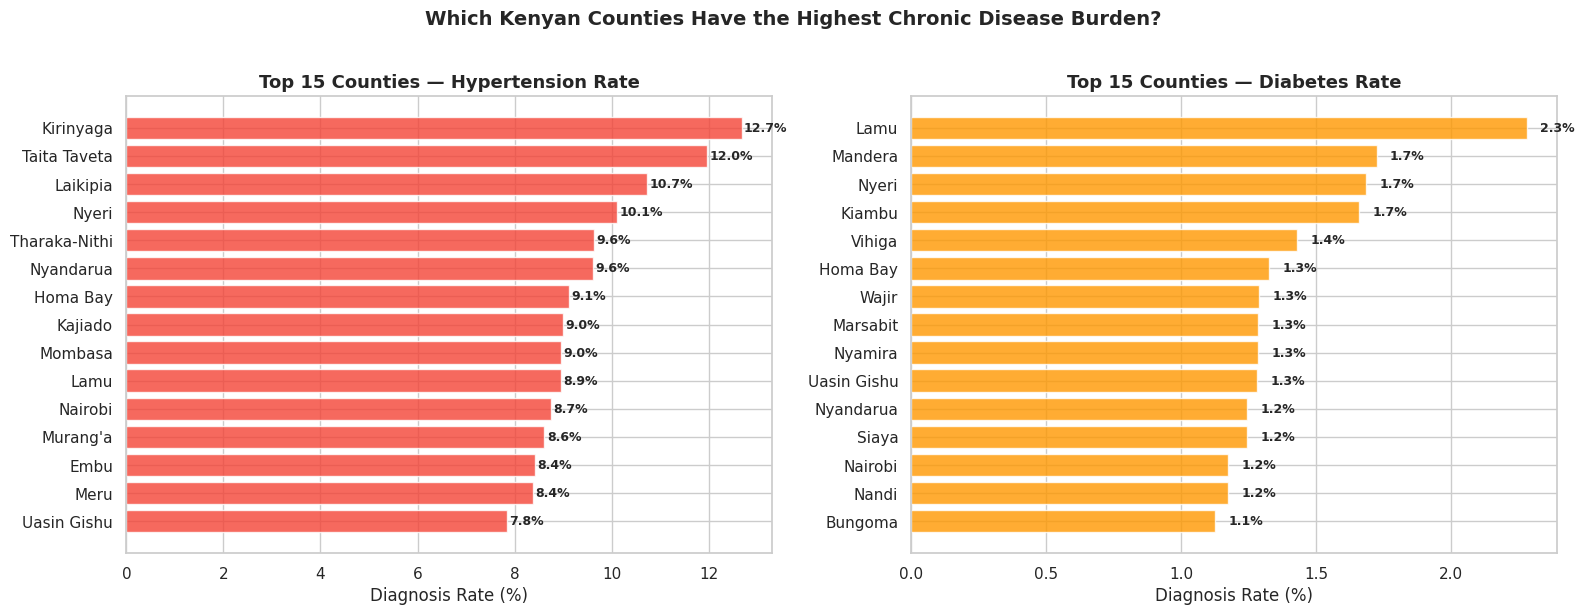

✅ Chart 7 saved


In [9]:
# ── Chart 7: Top 15 Counties by Hypertension Rate ────────────────────────
# Which counties have the highest chronic disease burden?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (disease, title, color) in enumerate(zip(
    ['hypertension', 'diabetes'],
    ['Hypertension', 'Diabetes'],
    ['#F44336', '#FF9800']
)):
    county_rate = df.groupby('county')[disease].mean() * 100
    top15 = county_rate.sort_values(ascending=True).tail(15)

    axes[i].barh(
        top15.index,
        top15.values,
        color=color,
        alpha=0.8,
        edgecolor='white'
    )
    axes[i].set_title(f'Top 15 Counties — {title} Rate',
                      fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Diagnosis Rate (%)')

    for j, val in enumerate(top15.values):
        axes[i].text(val + 0.05, j, f'{val:.1f}%',
                    va='center', fontsize=9, fontweight='bold')

plt.suptitle('Which Kenyan Counties Have the Highest Chronic Disease Burden?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart7_county_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved")

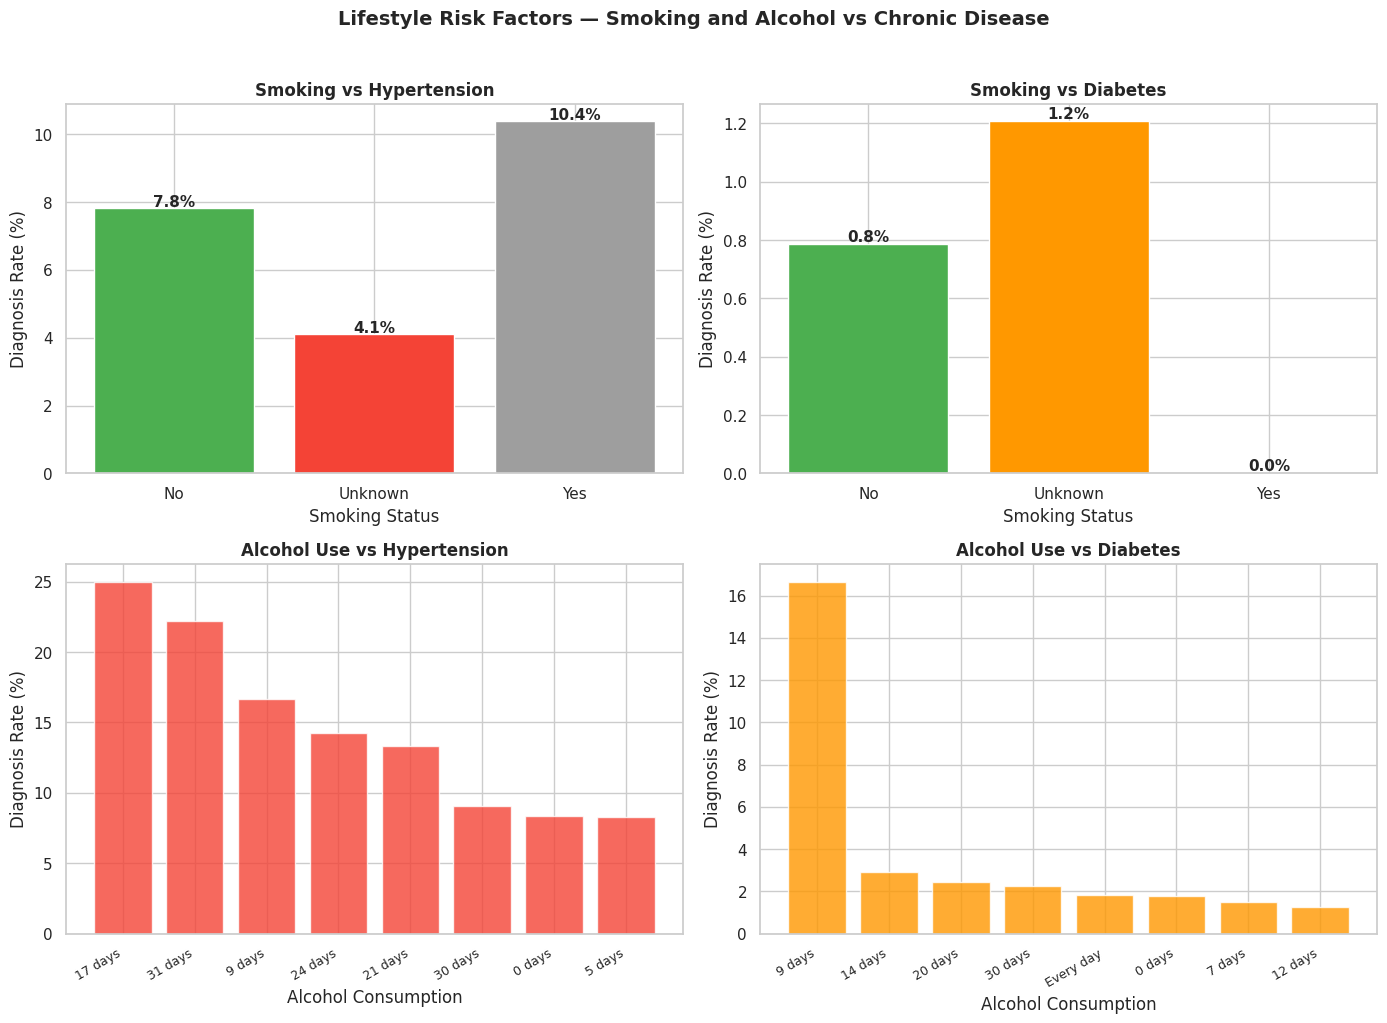

✅ Chart 8 saved


In [10]:
# ── Chart 8: Smoking and Alcohol vs Disease ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Smoking vs Hypertension
smoke_hyp = df.groupby('smokes')['hypertension'].mean() * 100
axes[0,0].bar(smoke_hyp.index, smoke_hyp.values,
              color=['#4CAF50','#F44336','#9E9E9E'], edgecolor='white')
axes[0,0].set_title('Smoking vs Hypertension', fontweight='bold')
axes[0,0].set_ylabel('Diagnosis Rate (%)')
axes[0,0].set_xlabel('Smoking Status')
for bar, val in zip(axes[0,0].patches, smoke_hyp.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05, f'{val:.1f}%',
                   ha='center', fontweight='bold')

# Smoking vs Diabetes
smoke_dia = df.groupby('smokes')['diabetes'].mean() * 100
axes[0,1].bar(smoke_dia.index, smoke_dia.values,
              color=['#4CAF50','#FF9800','#9E9E9E'], edgecolor='white')
axes[0,1].set_title('Smoking vs Diabetes', fontweight='bold')
axes[0,1].set_ylabel('Diagnosis Rate (%)')
axes[0,1].set_xlabel('Smoking Status')
for bar, val in zip(axes[0,1].patches, smoke_dia.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01, f'{val:.1f}%',
                   ha='center', fontweight='bold')

# Alcohol vs Hypertension
alcohol_hyp = df.groupby('alcohol_days')['hypertension'].mean() * 100
alcohol_hyp = alcohol_hyp.sort_values(ascending=False).head(8)
axes[1,0].bar(range(len(alcohol_hyp)), alcohol_hyp.values,
              color='#F44336', alpha=0.8, edgecolor='white')
axes[1,0].set_xticks(range(len(alcohol_hyp)))
axes[1,0].set_xticklabels(alcohol_hyp.index, rotation=30, ha='right', fontsize=9)
axes[1,0].set_title('Alcohol Use vs Hypertension', fontweight='bold')
axes[1,0].set_ylabel('Diagnosis Rate (%)')
axes[1,0].set_xlabel('Alcohol Consumption')

# Alcohol vs Diabetes
alcohol_dia = df.groupby('alcohol_days')['diabetes'].mean() * 100
alcohol_dia = alcohol_dia.sort_values(ascending=False).head(8)
axes[1,1].bar(range(len(alcohol_dia)), alcohol_dia.values,
              color='#FF9800', alpha=0.8, edgecolor='white')
axes[1,1].set_xticks(range(len(alcohol_dia)))
axes[1,1].set_xticklabels(alcohol_dia.index, rotation=30, ha='right', fontsize=9)
axes[1,1].set_title('Alcohol Use vs Diabetes', fontweight='bold')
axes[1,1].set_ylabel('Diagnosis Rate (%)')
axes[1,1].set_xlabel('Alcohol Consumption')

plt.suptitle('Lifestyle Risk Factors — Smoking and Alcohol vs Chronic Disease',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart8_lifestyle_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved")

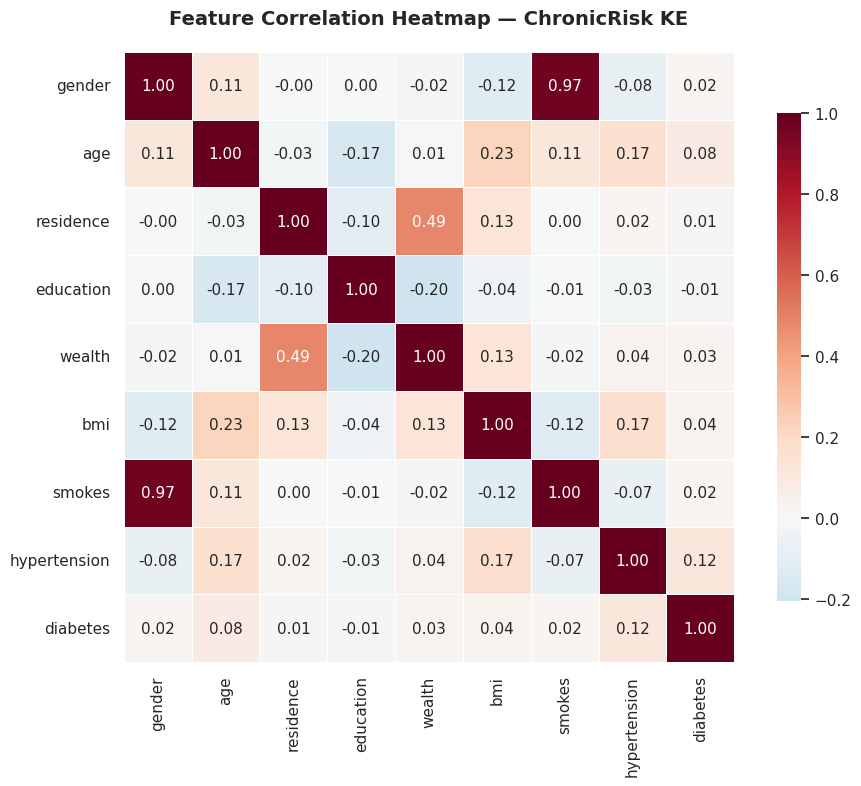

✅ Chart 9 saved


In [19]:
# ── Chart 9: Correlation Heatmap ─────────────────────────────────────────
# Which numerical features are most correlated with our target variables?

# Encode categorical columns temporarily for correlation
df_encoded = df.copy()
cat_cols = ['gender', 'residence', 'education', 'wealth', 'smokes']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Drop county — too many categories for simple correlation
df_encoded = df_encoded.drop(columns=['county', 'alcohol_days'])

corr = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap — ChronicRisk KE',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved")

## ✅ Phase 2 Complete — Key EDA Findings

| Finding | Insight |
|---|---|
| Disease prevalence | Hypertension 6.3%, Diabetes 1.0% — severe class imbalance |
| Age | Risk increases significantly after age 30 |
| BMI | Diagnosed patients have higher BMI — strong predictor |
| Gender | Women: higher hypertension. Men: higher diabetes |
| Residence | Urban residents have higher rates for both diseases |
| Wealth | Richer Kenyans show higher diagnosis rates |
| Counties | Kirinyaga (12.7%) and Lamu (2.3%) lead hypertension and diabetes |
| Class imbalance | SMOTE required before model training |

➡️ Next: `03_modelling.ipynb` — Model Building and Evaluation